# Supplementary Note: Matrix Rank

**Companion to Chapter 11: Linear Algebra & Matrices**

---

This note takes a deeper look at **rank** — one of the most important properties of a matrix. Understanding rank helps you answer three practical questions:

- Does my system of equations have a unique solution?
- Is this matrix invertible?
- How much independent information does this dataset contain?

## 1. Motivation — What Does "Rank" Mean?

The **rank** of a matrix tells us how much *independent* information it contains.

> **Rank = the number of linearly independent rows (or columns) in a matrix.**

Two rows are **linearly dependent** if one is just a scalar multiple (or linear combination) of the other — they carry no new information.

Think of it this way: if you have 3 balance equations but one is just "2 × equation 1", you really only have 2 independent constraints. That's a rank-2 system masquerading as a 3×3 system.

## 2. Formal Definition

For a matrix $A \in \mathbb{R}^{m \times n}$:

$$
\text{rank}(A) = \text{number of linearly independent rows} = \text{number of linearly independent columns}
$$

A fundamental theorem of linear algebra guarantees these two counts are **always equal** — a remarkable fact.

The rank is bounded by the smaller dimension:

$$
\text{rank}(A) \leq \min(m, n)
$$

We say $A$ has **full rank** when $\text{rank}(A) = \min(m, n)$.

## 3. Rank Works for Any Matrix Shape

Rank is not limited to square matrices:

| Matrix shape | Max possible rank | Limited by |
|---|---|---|
| $3 \times 3$ (square) | 3 | either |
| $5 \times 2$ (tall) | 2 | columns |
| $2 \times 5$ (wide) | 2 | rows |

For a system $A\mathbf{x} = \mathbf{b}$ to have a **unique solution**, we need $A$ to be square *and* have full rank.

## 4. Examples

Let's compute rank for several matrices and connect each result to a geometric and algebraic interpretation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### Example 1 — Full Rank Square Matrix

$$
A_1 = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
$$

Row 1 = $[1, 0]$ and Row 2 = $[0, 1]$ point in completely different directions — they are independent.

In [2]:
A1 = np.array([[1, 0],
               [0, 1]])

print("A1 =\n", A1)
print(f"rank(A1) = {np.linalg.matrix_rank(A1)}")
print(f"det(A1)  = {np.linalg.det(A1):.1f}  (non-zero → invertible)")

A1 =
 [[1 0]
 [0 1]]
rank(A1) = 2
det(A1)  = 1.0  (non-zero → invertible)


### Example 2 — Dependent Rows (Rank-Deficient)

$$
A_2 = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}
$$

Here $\text{Row}_2 = 2 \times \text{Row}_1$. The second row adds no new information.
This matrix is **singular** — it cannot be inverted, and $A_2\mathbf{x} = \mathbf{b}$ has either no solution or infinitely many.

In [3]:
A2 = np.array([[1, 2],
               [2, 4]])

print("A2 =\n", A2)
print(f"rank(A2) = {np.linalg.matrix_rank(A2)}  ← only 1 independent row")
print(f"det(A2)  = {np.linalg.det(A2):.1f}  (zero → singular, NOT invertible)")

try:
    np.linalg.solve(A2, np.array([1, 2]))
except np.linalg.LinAlgError as e:
    print(f"\nnp.linalg.solve error: {e}")

A2 =
 [[1 2]
 [2 4]]
rank(A2) = 1  ← only 1 independent row
det(A2)  = 0.0  (zero → singular, NOT invertible)

np.linalg.solve error: Singular matrix


### Example 3 — Rectangular (Tall) Matrix

$$
A_3 = \begin{bmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{bmatrix} \quad (3 \times 2)
$$

Maximum possible rank = $\min(3, 2) = 2$. There cannot be more independent directions than columns.

In [4]:
A3 = np.array([[1, 2],
               [3, 4],
               [5, 6]])

print("A3 =\n", A3)
print(f"Shape: {A3.shape}  →  max rank = min(3, 2) = 2")
print(f"rank(A3) = {np.linalg.matrix_rank(A3)}  (full rank for this shape)")

A3 =
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)  →  max rank = min(3, 2) = 2
rank(A3) = 2  (full rank for this shape)


### Example 4 — Partially Dependent Rows in a 3×3 Matrix

$$
A_4 = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 5 & 7 & 9 \end{bmatrix}
$$

Notice that $\text{Row}_3 = \text{Row}_1 + \text{Row}_2$. So despite being 3×3, this matrix only has rank 2.

In [5]:
A4 = np.array([[1, 2, 3],
               [4, 5, 6],
               [5, 7, 9]])   # row3 = row1 + row2

print("A4 =\n", A4)
print(f"Row1 + Row2 = {A4[0] + A4[1]}  ==  Row3 {A4[2]}  →  dependent!")
print(f"rank(A4) = {np.linalg.matrix_rank(A4)}  (rank-deficient 3×3)")
print(f"det(A4)  = {np.linalg.det(A4):.6f}  (≈ 0 → singular)")

A4 =
 [[1 2 3]
 [4 5 6]
 [5 7 9]]
Row1 + Row2 = [5 7 9]  ==  Row3 [5 7 9]  →  dependent!
rank(A4) = 2  (rank-deficient 3×3)
det(A4)  = 0.000000  (≈ 0 → singular)


## 5. Geometric Interpretation

Rank tells you the **dimension of the output space** (column space) of a linear transformation $\mathbf{y} = A\mathbf{x}$.

| Rank | What the transformation does to 2D space |
|------|-------------------------------------------|
| 2 | Maps the plane to the full plane (invertible) |
| 1 | Collapses the plane onto a **line** |
| 0 | Collapses everything to a **point** (zero matrix) |

The plot below shows this visually: a unit square transformed by a full-rank vs rank-1 matrix.

In [11]:
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])
square.shape

(2, 5)

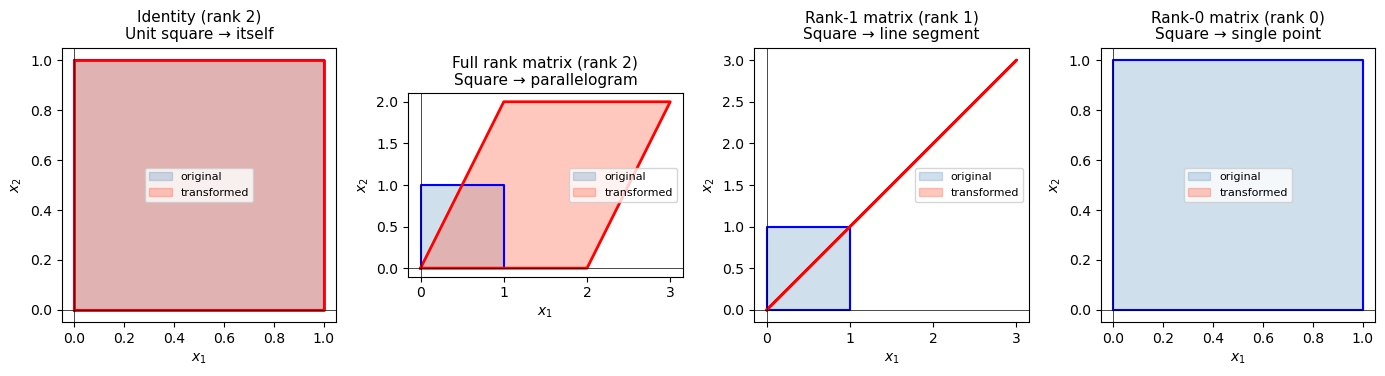

rank(A_full)  = 2
rank(A_rank1) = 1
rank(A_rank0) = 0


In [8]:
# Unit square corners
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

A_full = np.array([[2, 1],
                   [0, 2]])   # rank 2

A_rank1 = np.array([[1, 2],
                    [1, 2]])  # rank 1: row2 = row1

A_rank0 = np.zeros((2, 2))  # rank 0: all rows are zero

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

def plot_transform(ax, A, title):
    transformed = A @ square
    ax.fill(square[0], square[1], alpha=0.25, color='steelblue', label='original')
    ax.plot(square[0], square[1], 'b-', linewidth=1.5)
    ax.fill(transformed[0], transformed[1], alpha=0.35, color='tomato', label='transformed')
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Original (identity)
plot_transform(axes[0], np.eye(2), 'Identity (rank 2)\nUnit square → itself')
plot_transform(axes[1], A_full,  f'Full rank matrix (rank {np.linalg.matrix_rank(A_full)})\nSquare → parallelogram')
plot_transform(axes[2], A_rank1, f'Rank-1 matrix (rank {np.linalg.matrix_rank(A_rank1)})\nSquare → line segment')
plot_transform(axes[3], A_rank0, f'Rank-0 matrix (rank {np.linalg.matrix_rank(A_rank0)})\nSquare → single point')

plt.tight_layout()
plt.show()

print(f"rank(A_full)  = {np.linalg.matrix_rank(A_full)}")
print(f"rank(A_rank1) = {np.linalg.matrix_rank(A_rank1)}")
print(f"rank(A_rank0) = {np.linalg.matrix_rank(A_rank0)}")

## 6. Why Rank Matters in Chemical Engineering

### 6.1 Material Balances

When setting up a system of balance equations, the coefficient matrix $A$ may be rank-deficient if:
- You wrote the same balance twice (e.g., an overall balance that is just the sum of two component balances)
- Two streams have identical compositions (no independent information)

If $\text{rank}(A) < n$ (number of unknowns), the system is **underdetermined** — you need more independent measurements.

### 6.2 Degrees of Freedom Analysis

The **degrees of freedom** (DOF) of a system is:

$$
\text{DOF} = n_{\text{unknowns}} - \text{rank}(A)
$$

| DOF | Meaning |
|-----|---------|
| 0 | Exactly determined — unique solution |
| > 0 | Underdetermined — need more equations or measurements |
| < 0 | Overdetermined — conflicting equations |

### 6.3 Checking Your Balance Before Solving

In [7]:
def check_system(A, b, unknowns):
    """Diagnose an Ax=b system before attempting to solve."""
    m, n = A.shape
    r = np.linalg.matrix_rank(A)
    dof = n - r

    print(f"Matrix size : {m} equations × {n} unknowns")
    print(f"Unknowns    : {unknowns}")
    print(f"rank(A)     = {r}")
    print(f"DOF         = {n} - {r} = {dof}")

    if dof == 0 and m == n:
        print("→ System is exactly determined. Proceed with np.linalg.solve.")
    elif dof > 0:
        print(f"→ Underdetermined: {dof} free variable(s). Need more independent equations.")
    else:
        print("→ Overdetermined or inconsistent. Check for redundant equations.")


# --- Well-posed system ---
print("=== Well-posed mixer balance ===")
A_ok = np.array([[1.0, 1.0],
                 [0.4, 0.8]])
b_ok = np.array([100.0, 60.0])
check_system(A_ok, b_ok, ['F1', 'F2'])

print()

# --- Rank-deficient system (redundant balance) ---
print("=== Rank-deficient system (row2 = 2×row1) ===")
A_bad = np.array([[1.0, 1.0],
                  [2.0, 2.0]])
b_bad = np.array([100.0, 200.0])
check_system(A_bad, b_bad, ['F1', 'F2'])

=== Well-posed mixer balance ===
Matrix size : 2 equations × 2 unknowns
Unknowns    : ['F1', 'F2']
rank(A)     = 2
DOF         = 2 - 2 = 0
→ System is exactly determined. Proceed with np.linalg.solve.

=== Rank-deficient system (row2 = 2×row1) ===
Matrix size : 2 equations × 2 unknowns
Unknowns    : ['F1', 'F2']
rank(A)     = 1
DOF         = 2 - 1 = 1
→ Underdetermined: 1 free variable(s). Need more independent equations.


## 7. Summary

| Concept | Key point |
|---------|----------|
| **Rank** | Number of linearly independent rows = columns |
| **Full rank** | $\text{rank}(A) = \min(m, n)$ — maximum possible |
| **Rank-deficient** | At least one row/column is a combination of others |
| **Unique solution** | Requires square $A$ with full rank (det ≠ 0) |
| **DOF = 0** | $\text{rank}(A) = n_{\text{unknowns}}$ — exactly solvable |
| **NumPy function** | `np.linalg.matrix_rank(A)` |

**Rule of thumb before calling `np.linalg.solve`:**
1. Check that $A$ is square: `A.shape[0] == A.shape[1]`
2. Check full rank: `np.linalg.matrix_rank(A) == A.shape[0]`
3. Or equivalently: `np.linalg.det(A) != 0`

If either check fails, you have a modeling problem — not a coding problem.